# FITE Classification Challenge

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

في هذا المشروع نتعامل مع مسألة تصنيف متعددة الكلاسات على بيانات مجهولة الأعمدة. الهدف هو بناء Pipeline واضح وقابل لإعادة التشغيل، يبدأ من فهم الداتا وينتهي بتوليد ملف `submission.csv`.

## ما هي المشكلة؟
عندنا داتا تحتوي على أعمدة `f1` إلى `f21`. معنى الأعمدة غير معروف، لذلك نعتمد على التحليل الإحصائي، جودة الـ validation، وتجربة عدة موديلات بدل استخدام افتراضات خارجية عن معنى الخصائص.

## الفكرة العامة للحل
- نفهم شكل الداتا قبل التدريب.
- نكشف هل فيها missing values أو imbalance.
- نستخدم validation داخلي بدل الاعتماد الكامل على public leaderboard.
- نجرب أكثر من موديل ونقارن النتائج.
- نسجل التجارب في MLflow.
- ندير ملفات الداتا عن طريق DVC بدل رفع CSV مباشرة على GitHub.

## ملاحظة عن Public و Private
نتيجة Public leaderboard لا تمثل دائما الأداء النهائي، لأن جزءا من test يبقى Private. لذلك نعتمد أساسا على `StratifiedKFold Macro F1` لاختيار التحسينات، ونستخدم نتيجة Kaggle كفحص إضافي وليس كمعيار وحيد.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 1. تجهيز المكتبات والإعدادات

في هذه الخلية نجهز المكتبات الأساسية ونثبت `RANDOM_STATE` حتى تكون النتائج قابلة للإعادة. هذه الخطوة تجعل التجارب أكثر ثباتا، وتساعدنا نقارن بين الموديلات بدون أن يتغير التقسيم أو التدريب عشوائيا كل مرة.

نستخدم مكتبات مثل `pandas` و `numpy` للتعامل مع الداتا، و `matplotlib` للرسومات، و `sklearn` للتحليل والتقييم.

</div>

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
ARTIFACT_DIR = Path("classification_artifacts")

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 2. قراءة الداتا وفحص الشكل العام

هنا نقرأ ملفات `train_data.csv` و `test_data.csv` و `sample_submission.csv`. نطبع عدد الصفوف والأعمدة، ونقارن أعمدة train و test حتى نتأكد أنه لا يوجد اختلاف غريب بينهما.

</div>

In [2]:
train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)
sample_submission = pd.read_csv(SAMPLE_FILE)

ID_COL = "ID"
TARGET_COL = "target"
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

assert TARGET_COL in train.columns
assert TARGET_COL not in test.columns
assert feature_cols == [c for c in test.columns if c != ID_COL]
assert sample_submission[ID_COL].tolist() == test[ID_COL].tolist()

basic_checks = pd.DataFrame({
    "الفحص": [
        "شكل train", "شكل test", "عدد الخصائص", "القيم المفقودة في train", "القيم المفقودة في test",
        "ID فريد في train", "ID فريد في test", "صفوف مكررة حسب الخصائص في train", "صفوف مكررة حسب الخصائص في test"
    ],
    "القيمة": [
        train.shape, test.shape, len(feature_cols), int(train.isna().sum().sum()), int(test.isna().sum().sum()),
        bool(train[ID_COL].is_unique), bool(test[ID_COL].is_unique), int(train[feature_cols].duplicated().sum()), int(test[feature_cols].duplicated().sum())
    ]
})

display(basic_checks)
display(train.head())
display(test.head())

,الفحص,القيمة
0,شكل train,"(3200, 23)"
1,شكل test,"(3200, 22)"
2,عدد الخصائص,21
3,القيم المفقودة في train,0
4,القيم المفقودة في test,0
5,ID فريد في train,True
6,ID فريد في test,True
7,صفوف مكررة حسب الخصائص في train,57
8,صفوف مكررة حسب الخصائص في test,7


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.57,0.023,0,1,0,0,0,0,0.115,0.00600,0,1,1,0.11954,0,0,0,0,0,0.096,0
1,10001,0.54,0.013,1,0,0,0,0,0,0.102,0.00085,0,0,0,0.11300,0,0,0,0,0,0.091,0
2,10002,0.56,0.019,0,1,0,0,0,0,0.096,0.00097,0,0,0,0.10300,0,0,0,0,0,0.093,0
3,10003,0.26,0.023,1,0,0,0,0,0,0.096,0.00110,0,0,0,0.12300,0,0,0,0,0,0.078,0
4,10004,0.60,0.023,0,1,1,0,0,0,0.155,0.00004,0,1,0,0.22100,0,0,0,1,0,0.070,0


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نستنتج من هذه الخلية؟

نريد التأكد من ثلاث نقاط: عدد صفوف train و test واضح، و test لا يحتوي على `target`، ونفس ميزات التدريب موجودة في test. إذا ظهر اختلاف في الأعمدة، فهذا يعني أن الـ pipeline قد يتعطل وقت التنبؤ.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 3. توزيع الكلاسات ولماذا Macro F1؟

هذه من أهم الخلايا. نحن لا نكتفي بالـ Accuracy لأن الداتا غير متوازنة. إذا class واحدة كبيرة جدا، ممكن موديل بسيط يتوقعها دائما ويأخذ Accuracy عالية، لكنه يفشل في الكلاسات الصغيرة.

لذلك نستخدم `Macro F1` لأنه يحاسب كل class بشكل أقرب للعدل، ثم يأخذ المتوسط بين الكلاسات.

</div>

,count,percentage
target,,
class1,93,2.906
class2,191,5.969
class3,2916,91.125


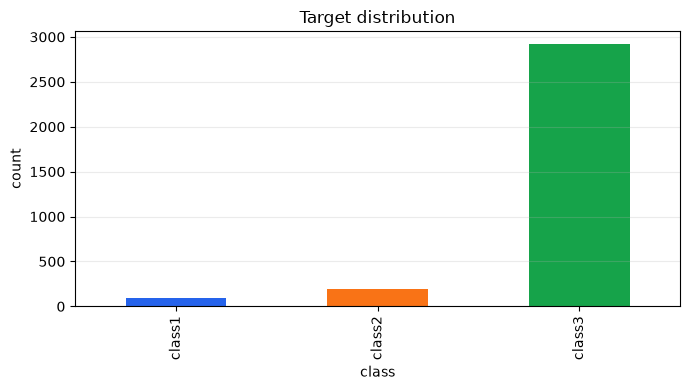

In [3]:
target_counts = train[TARGET_COL].value_counts().sort_index()
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(train) * 100).round(3)
})
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Target distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### الاستنتاج من توزيع الهدف

إذا رأينا أن `class3` مثلا أكبر بكثير من باقي الكلاسات، فهذا يبرر استخدام `StratifiedKFold`، واستخدام `class_weight='balanced'` في بعض الموديلات، والتركيز على `Macro F1` وليس Accuracy فقط.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 4. فهم أنواع الخصائص

بما أن الأعمدة anonymized، لا نعرف معناها الحقيقي. لذلك نحللها إحصائيا: إذا كانت القيم فقط 0 و 1 نعتبرها binary feature، وإذا كانت قيمها كثيرة ومستمرة نعتبرها continuous feature.

</div>

In [4]:
binary_features = []
continuous_features = []
for c in feature_cols:
    train_values = set(train[c].dropna().unique())
    test_values = set(test[c].dropna().unique())
    if train_values.issubset({0, 1, 0.0, 1.0}) and test_values.issubset({0, 1, 0.0, 1.0}):
        binary_features.append(c)
    else:
        continuous_features.append(c)

feature_type_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "train_nunique": [train[c].nunique() for c in feature_cols],
    "test_nunique": [test[c].nunique() for c in feature_cols],
    "train_mean": [train[c].mean() for c in feature_cols],
    "test_mean": [test[c].mean() for c in feature_cols],
})
feature_type_df["abs_mean_diff"] = (feature_type_df["train_mean"] - feature_type_df["test_mean"]).abs()

display(feature_type_df.sort_values(["type", "abs_mean_diff"], ascending=[True, False]))
print("Binary:", binary_features)
print("Continuous:", continuous_features)

,feature,type,train_nunique,test_nunique,train_mean,test_mean,abs_mean_diff
17,f18,binary,2,2,0.059375,0.077188,0.017813
11,f12,binary,2,2,0.122813,0.139375,0.016562
6,f7,binary,2,2,0.005000,0.020938,0.015938
12,f13,binary,2,2,0.061875,0.069687,0.007812
7,f8,binary,2,2,0.012188,0.018437,0.006250
20,f21,binary,2,2,0.013437,0.007500,0.005938
4,f5,binary,2,2,0.014687,0.019062,0.004375
14,f15,binary,2,2,0.011250,0.014063,0.002813
2,f3,binary,2,2,0.045000,0.046562,0.001563
5,f6,binary,2,2,0.038750,0.037187,0.001563


Binary: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نستفيد؟

هذا الفحص يعطينا خريطة بسيطة للداتا. بدل ما نقول “الأعمدة مجهولة وما نعرف ماذا نفعل”، نعاملها حسب سلوكها الإحصائي. وجود ميزات binary كثيرة يجعل موديلات الأشجار مناسبة لأنها تتعامل جيدا مع التقسيمات الشرطية.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 5. مقارنة Train و Test بدون تسريب

هذه الخلية تقارن توزيع الخصائص بين train و test. هذا لا يعتبر leakage لأننا لا نستخدم target الخاص بالـ test، ولا نعمل lookup على صفوف test.

الهدف فقط أن نعرف هل test يشبه train أم يوجد drift كبير. إذا كان الاختلاف كبيرا، ممكن public/private score يختلف، وهذا بالضبط من الأشياء التي نبه عليها الدكتور.

</div>

,feature,type,train_mean,test_mean,abs_mean_diff
17,f18,binary,0.059375,0.077188,0.017813
11,f12,binary,0.122813,0.139375,0.016562
6,f7,binary,0.005000,0.020938,0.015938
0,f1,continuous,0.516861,0.526824,0.009963
12,f13,binary,0.061875,0.069687,0.007812
13,f14,continuous,0.109880,0.116732,0.006852
7,f8,binary,0.012188,0.018437,0.006250
20,f21,binary,0.013437,0.007500,0.005938
4,f5,binary,0.014687,0.019062,0.004375
8,f9,continuous,0.107968,0.110992,0.003023


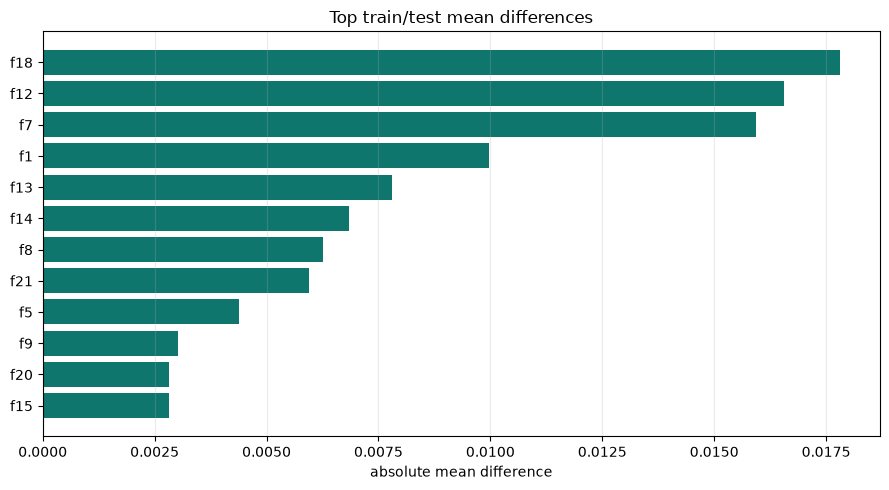

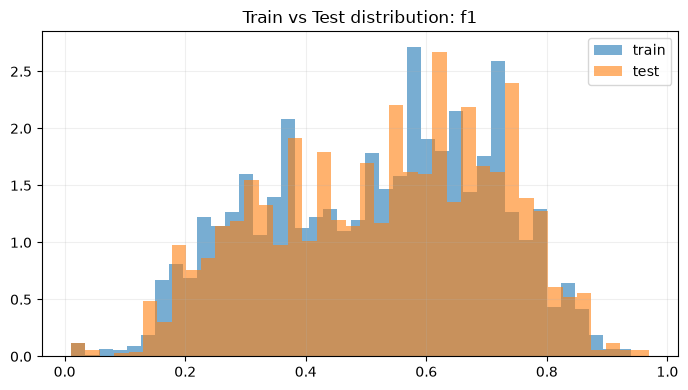

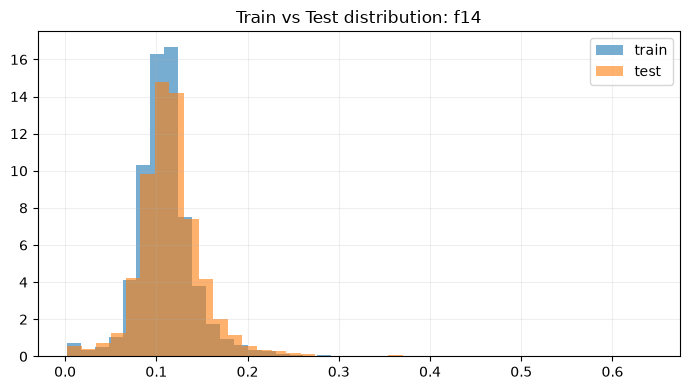

In [5]:
drift_df = feature_type_df.sort_values("abs_mean_diff", ascending=False)
display(drift_df[["feature", "type", "train_mean", "test_mean", "abs_mean_diff"]].head(12))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = drift_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["abs_mean_diff"], color="#0f766e")
ax.set_title("Top train/test mean differences")
ax.set_xlabel("absolute mean difference")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

for c in [x for x in drift_df["feature"].head(6) if x in continuous_features]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[c], bins=40, alpha=0.6, density=True, label="train")
    ax.hist(test[c], bins=40, alpha=0.6, density=True, label="test")
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### الاستنتاج من Train/Test Drift

إذا كانت الفروق بين train و test صغيرة، فهذا يطمئننا أن validation قد يكون قريب من Kaggle. أما إذا كانت بعض الميزات مختلفة كثيرا، فهذا يعني أن Public leaderboard قد لا يمثل الحقيقة كاملة، وأن أي تحسين صغير على public ليس بالضرورة تحسين حقيقي.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 6. أهمية الخصائص من التدريب فقط

هنا نستخدم طرق تحليل مثل `Mutual Information` و `ANOVA F-score` على بيانات التدريب فقط. الهدف معرفة أي features تبدو مرتبطة أكثر بالـ target.

مهم: لا نستخدم `true_values.csv` ولا target الخاص بالـ test، لأن هذا ممنوع ويعتبر leakage.

</div>

,feature,type,mutual_information,anova_f_score,anova_pvalue
9,f10,continuous,0.281781,991.761826,0.000000e+00
13,f14,continuous,0.137953,331.484714,1.502435e-131
8,f9,continuous,0.108202,283.363477,5.076408e-114
1,f2,continuous,0.092057,117.512854,5.669935e-50
11,f12,binary,0.020573,14.852188,3.798027e-07
12,f13,binary,0.012737,14.289268,6.634724e-07
0,f1,continuous,0.012244,0.572002,5.644521e-01
16,f17,binary,0.009627,1.553742,2.116149e-01
19,f20,continuous,0.009546,3.082477,4.598183e-02
15,f16,binary,0.004152,1.177318,3.082374e-01


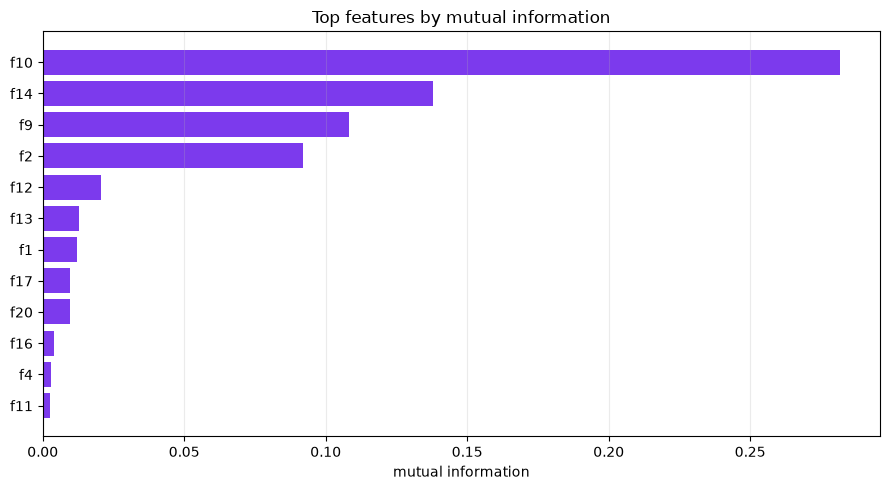

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(train[TARGET_COL])
class_names = list(le.classes_)

mi_scores = mutual_info_classif(train[feature_cols], y_encoded, random_state=RANDOM_STATE)
f_scores, f_pvalues = f_classif(train[feature_cols], y_encoded)
feature_score_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "mutual_information": mi_scores,
    "anova_f_score": f_scores,
    "anova_pvalue": f_pvalues,
}).sort_values("mutual_information", ascending=False)

display(feature_score_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = feature_score_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_information"], color="#7c3aed")
ax.set_title("Top features by mutual information")
ax.set_xlabel("mutual information")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نستنتج؟

الميزات ذات scores أعلى غالبا تحمل معلومات أقوى للتصنيف. هذا لا يعني أن باقي الميزات بلا فائدة، لأن بعض الموديلات تستفيد من التفاعلات بين الميزات. هذه الخلية تساعدنا نشرح لماذا جربنا Feature Engineering وتفاعلات بين بعض الأعمدة.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 7. الربط مع المحاضرات

من المحاضرات استخدمنا أفكار واضحة:
- من Model Evaluation استخدمنا Cross Validation و Macro F1.
- من Preprocessing و Feature Engineering تعاملنا مع الأعمدة رقميا وإحصائيا بدل افتراض معاني غير موجودة.
- من Ensemble Learning استخدمنا أكثر من موديل ودمجنا احتمالاتهم.
- من Imbalanced Data انتبهنا لمشكلة عدم توازن الكلاسات.

هذا الجزء مهم في المناقشة الشفهية، لأن أي عضو بالفريق لازم يعرف لماذا هذه الخطوات موجودة.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 8. تشغيل الـ Pipeline النهائي

هنا نشغل الملف `classification_pipeline.py`. وضعنا الكود التدريبي الأساسي في ملف Python حتى يكون النوتبوك نظيف، ولأن هذا أقرب لطريقة المشاريع العملية: النوتبوك للشرح والتحليل، والملف البرمجي للتنفيذ القابل للإعادة.

الـ pipeline يعمل Feature Engineering عام، يدرب عدة موديلات، يستخدم `StratifiedKFold`، يحسب Accuracy و Macro F1، يبني Ensemble، يسجل التجارب في MLflow، ويولد `submission.csv`.

</div>

In [7]:
%run classification_pipeline.py

MLflow logging is enabled.
Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class1    0.0291
class2    0.0597
class3    0.9112
lightgbm_simple_fe           fold 1: acc=0.99687 bal_acc=0.99886 f1_macro=0.98609
lightgbm_simple_fe           fold 2: acc=0.99844 bal_acc=0.99943 f1_macro=0.99549
lightgbm_simple_fe           fold 3: acc=0.99844 bal_acc=0.99943 f1_macro=0.99538
lightgbm_simple_fe           fold 4: acc=0.99375 bal_acc=0.98131 f1_macro=0.97698
lightgbm_simple_fe           fold 5: acc=0.99844 bal_acc=0.99943 f1_macro=0.99117
lightgbm_original            fold 1: acc=0.99687 bal_acc=0.99886 f1_macro=0.98609
lightgbm_original            fold 2: acc=0.99844 bal_acc=0.99943 f1_macro=0.99549
lightgbm_original            fold 3: acc=0.99844 bal_acc=0.99943 f1_macro=0.99538
lightgbm_original            fold 4: acc=0.99062 bal_acc=0.97197 f1_macro=0.96752
lightgbm_original            fold 5: acc=1.00000 bal_acc=1.00000 f1_macro=1.00000
random_forest_original    

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 9. قراءة نتائج التدريب والـ Artifacts

بعد تشغيل الـ pipeline، نقرأ الملفات التي تولدت داخل `classification_artifacts`: نتائج cross-validation، معلومات الـ ensemble والأوزان، classification report، confusion matrix، وتوزيع توقعات test.

</div>

In [8]:
cv_results = pd.read_csv(ARTIFACT_DIR / "cv_results.csv")
course_baselines = pd.read_csv(ARTIFACT_DIR / "course_baseline_results.csv")
robust_by_seed = pd.read_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv")
robust_summary = pd.read_csv(ARTIFACT_DIR / "robust_validation_summary.csv")

with open(ARTIFACT_DIR / "ensemble_info.json", "r", encoding="utf-8") as f:
    ensemble_info = json.load(f)
report_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv", index_col=0)
cm_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv", index_col=0)
submission = pd.read_csv("submission.csv")

print("Weight strategy:", ensemble_info.get("weight_strategy"))
print("OOF Macro F1:", ensemble_info.get("oof_f1_macro"))
print("OOF Accuracy:", ensemble_info.get("oof_accuracy"))

display(cv_results.sort_values("f1_macro_mean", ascending=False))
display(pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight", ascending=False))
display(report_df)
display(cm_df)


Weight strategy: random_dirichlet
OOF Macro F1: 0.9926385075878899
OOF Accuracy: 0.998125


,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,folds
0,lightgbm_simple_fe,0.997188,0.001822,0.995691,0.989023,"[0.996875, 0.9984375, 0.9984375, 0.99375, 0.99..."
1,lightgbm_original,0.996875,0.003278,0.993937,0.988897,"[0.996875, 0.9984375, 0.9984375, 0.990625, 1.0]"
2,gradient_boosting_fe,0.996250,0.002119,0.996988,0.987355,"[0.996875, 0.99375, 0.9984375, 0.99375, 0.9984..."
3,random_forest_original,0.996875,0.002210,0.990233,0.986545,"[0.9953125, 0.99375, 0.9984375, 0.996875, 1.0]"
4,hgb_simple_fe,0.996563,0.003187,0.987034,0.985193,"[0.996875, 0.9984375, 0.996875, 0.990625, 1.0]"
5,hgb_original,0.995625,0.003337,0.986850,0.983546,"[0.9953125, 0.99375, 0.9984375, 0.990625, 1.0]"
6,xgboost_simple_fe,0.995625,0.002688,0.981461,0.978264,"[0.9953125, 0.996875, 0.9984375, 0.990625, 0.9..."
7,extra_trees_original,0.976562,0.004739,0.844381,0.892186,"[0.9703125, 0.984375, 0.9765625, 0.9734375, 0...."


,model,weight
2,random_forest_original,0.364189
3,extra_trees_original,0.249367
7,gradient_boosting_fe,0.160047
0,lightgbm_simple_fe,0.134910
1,lightgbm_original,0.052261
5,hgb_simple_fe,0.021655
6,xgboost_simple_fe,0.010611
4,hgb_original,0.006961


,precision,recall,f1-score,support
class1,0.978947,1.000000,0.989362,93.000000
class2,0.984456,0.994764,0.989583,191.000000
class3,0.999657,0.998285,0.998970,2916.000000
accuracy,0.998125,0.998125,0.998125,0.998125
macro avg,0.987687,0.997683,0.992639,3200.000000
weighted avg,0.998147,0.998125,0.998131,3200.000000


,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,190,1
true_class3,2,3,2911


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نبحث عنه في النتائج؟

نقارن الموديلات بناء على `f1_macro_mean` وليس public score فقط. إذا كان موديل أفضل على validation، فهو غالبا أمتن على private leaderboard. كذلك ننظر إلى confusion matrix لمعرفة أين تتركز الأخطاء.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 10. توثيق التجارب الإضافية من المحاضرات

حتى لا يظهر الحل وكأنه قفز مباشرة إلى أفضل موديل، أضفنا Baselines أبسط من أفكار المحاضرات: KNN، Logistic Regression، Decision Tree، Bagging، وAdaBoost.

هذه التجارب لا تدخل تلقائيا في ملف الرفع. الهدف منها توثيق مسار الاختيار: نجرب، نقارن على validation، ثم نقرر هل تستحق الدخول في الحل النهائي أم لا.

</div>

In [ ]:
display(course_baselines.sort_values("f1_macro_mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
base_plot = course_baselines.sort_values("f1_macro_mean")
ax.barh(base_plot["model_name"], base_plot["f1_macro_mean"], color="#0f766e")
ax.set_title("Course-inspired baseline models: Macro F1")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نستنتج من Baselines؟

بعض النماذج البسيطة كانت قوية، خصوصا Decision Tree وBagging، وهذا منطقي لأن الداتا فيها أنماط شرطية واضحة. لكن الـ Ensemble النهائي بقي أعلى من هذه التجارب، لذلك استخدمناها كدليل مقارنة وليس كحل نهائي.

KNN وLogistic Regression كانا أضعف، وهذا يوضح أن المسألة ليست مجرد مسافة بين الصفوف أو حدود خطية بسيطة.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 11. Robust Validation Check

هنا نفحص هل الموديلات القوية تبقى قوية إذا غيرنا تقسيم الـ Cross Validation. استخدمنا عدة قيم لـ `random_state` بدل الاعتماد على split واحد.

إذا بقي Macro F1 قريبا عبر seeds مختلفة، فهذا يعطينا ثقة أكبر أن النتيجة ليست صدفة من تقسيم واحد، ويقلل خطر الاعتماد الزائد على Public leaderboard.

</div>

In [ ]:
display(robust_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
robust_plot = robust_summary.sort_values("f1_macro_mean_over_seeds")
axes[0].barh(robust_plot["model_name"], robust_plot["f1_macro_mean_over_seeds"], color="#2563eb")
axes[0].set_title("Mean Macro F1 across CV seeds")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

for model_name, group in robust_by_seed.groupby("model_name"):
    axes[1].plot(group["random_state"], group["f1_macro_mean"], marker="o", label=model_name)
axes[1].set_title("Macro F1 stability by random_state")
axes[1].set_xlabel("CV random_state")
axes[1].set_ylabel("Macro F1")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا نستنتج من Robust Validation؟

الموديلات القوية بقيت قريبة عبر أكثر من seed، وهذا يدعم أن الاختيار ليس مبنيا على split واحد فقط. إذا ظهر موديل يتذبذب كثيرا بين seeds، نتعامل معه بحذر حتى لو كانت نتيجته في split واحد عالية.

بهذه الطريقة يصبح قرار اختيار الموديل مبنيا على ثبات validation، وليس فقط على رقم واحد أو على نتيجة Public leaderboard.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 12. رسومات مقارنة الموديلات والـ Ensemble

الرسومات هنا ليست للزينة. هي تساعدنا نشرح بسرعة أي موديلات كانت أقوى في الـ validation، وكيف توزعت أوزان الـ ensemble، وهل الاعتماد كان على موديل واحد أم دمج عدة موديلات.

</div>

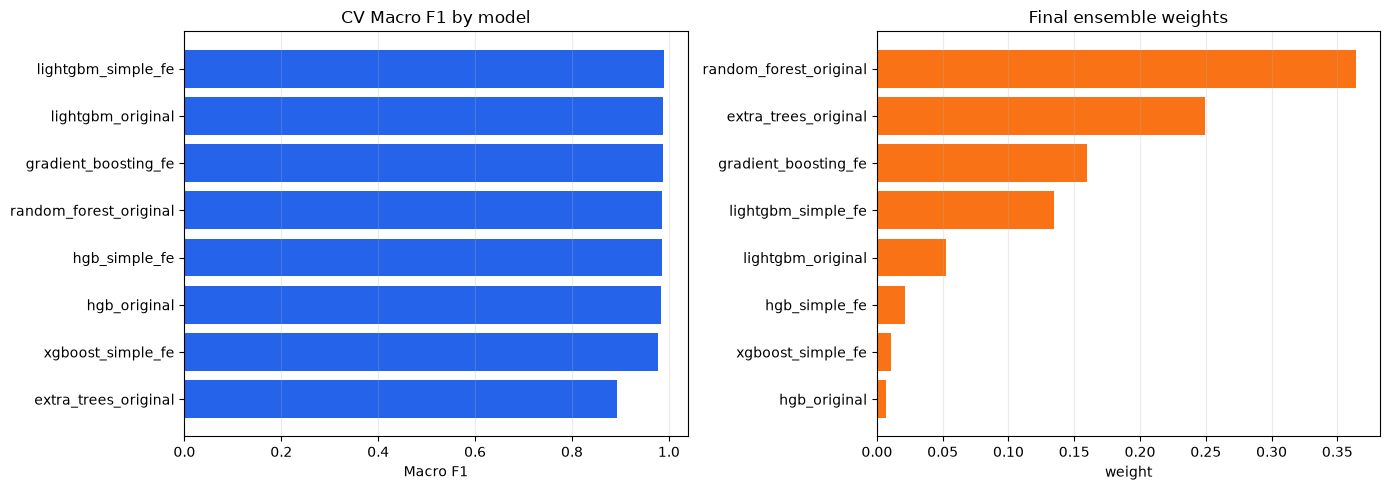

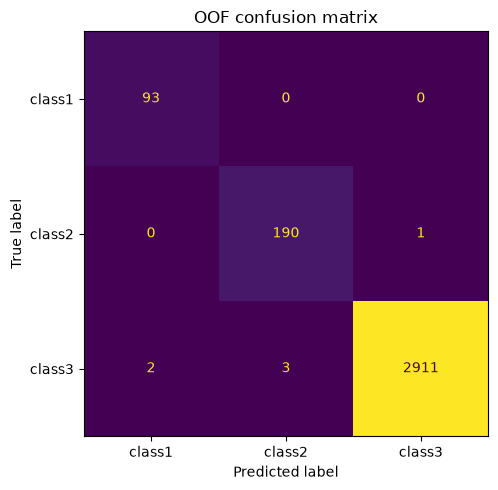

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = cv_results.sort_values("f1_macro_mean")
axes[0].barh(plot_df["model_name"], plot_df["f1_macro_mean"], color="#2563eb")
axes[0].set_title("CV Macro F1 by model")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

weights_df = pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight")
axes[1].barh(weights_df["model"], weights_df["weight"], color="#f97316")
axes[1].set_title("Final ensemble weights")
axes[1].set_xlabel("weight")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_df.values, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("OOF confusion matrix")
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### الاستنتاج من الرسومات

إذا رأينا أن أكثر من موديل يعطي نتائج قريبة، فالـ ensemble منطقي لأنه يقلل الاعتماد على قرار موديل واحد. أما إذا موديل واحد متفوق جدا والباقي ضعيف، وقتها قد يكون الدمج غير مفيد.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 13. فحص ملف الرفع

قبل رفع `submission.csv` إلى Kaggle، نفحصه: هل الأعمدة بالترتيب الصحيح؟ هل كل IDs موجودة؟ هل يوجد null؟ وهل كل target من الكلاسات المعروفة؟ هذه فحوصات بسيطة لكنها تمنع أخطاء قاتلة في الرفع.

</div>

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


target
class1      81
class2     188
class3    2931
Name: count, dtype: int64

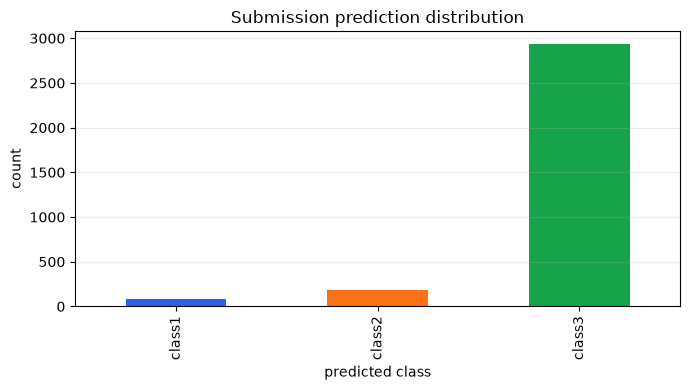

In [10]:
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert submission[ID_COL].tolist() == sample_submission[ID_COL].tolist()
assert submission[TARGET_COL].notna().all()
assert set(submission[TARGET_COL].unique()).issubset(set(class_names))

display(submission.head())
display(submission[TARGET_COL].value_counts().sort_index().rename("count"))

fig, ax = plt.subplots(figsize=(7, 4))
submission[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Submission prediction distribution")
ax.set_xlabel("predicted class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### الاستنتاج النهائي من ملف الرفع

إذا مرت كل assert بدون خطأ، فالملف جاهز للرفع. الملف لم يُبن يدويا ولم نستخدم target خاص بالـ test. هو ناتج من الموديلات المدربة على train فقط.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 14. كيف نقرأ الفرق بين Public و Private؟

إذا لاحظنا أن بعض الفرق تتحسن على Public ثم تنزل على Private. هذا يعني أن الفريق ربما صار يضبط الحل على public leaderboard بدل validation حقيقي.

لذلك نحن نتبع قاعدة بسيطة:
- إذا التحسين أفضل على validation وأيضا لا يضر public بشكل واضح، فهو مرشح جيد.
- إذا التحسين فقط رفع public قليلا لكن validation لم يتحسن، لا نعتبره تحسين قوي.
- إذا النتائج متعارضة، نعتبر التحسين غير significant بما يكفي.

بهذه الطريقة نقدر ندافع عن الحل أكاديميا: نحن لا نطارد public فقط، بل نبني قرارنا على validation وتصميم تجارب واضح.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 15. MLflow و DVC في المشروع

### MLflow
استخدمناه لتسجيل التجارب: اسم الموديل، المعاملات، ونتائج مثل Accuracy و Macro F1. المطلوب في التسليم أن نعرض Screenshot من MLflow UI يبين جدول المقارنة بين runs.

### DVC
استخدمناه لتتبع ملفات الداتا بدون رفع ملفات CSV مباشرة على GitHub. ملفات `.dvc` الصغيرة تدخل GitHub، أما الداتا نفسها تحفظ في Google Drive remote.

هذا يحقق فكرة MLOps: الكود قابل للتتبع، الداتا قابلة للاسترجاع، والتجارب قابلة للمقارنة.

</div>